# Классификация стадий сна — Стекинг SVM + LightGBM

**Задача.** Предсказать стадию сна (`sleep_stage` ∈ {0,1,2,3}). **Метрика.** macro-F1.

Две модели по отдельности упёрлись в потолок: **RBF-SVM ≈ 0.834**, **LightGBM ≈ 0.825**. Поодиночке LightGBM
слабее, но он **ошибается на других объектах** (деревья vs гладкая граница) — а именно разнородность баз
и делает стекинг осмысленным.

**Идея стекинга (без утечки):**
1. Каждая база даёт **out-of-fold вероятности** — предсказания для строки делает модель, которая её не видела.
   Эти OOF-вероятности становятся **мета-признаками**.
2. **Мета-классификатор** (логистическая регрессия) учится по мета-признакам, как лучше взвесить базы по классам.
3. Для test: базы переобучаются на всех train-данных → их вероятности → мета-модель даёт финальный ответ.

Сравниваем честно: базы → простой блендинг (среднее) → стекинг через мета-модель. После каждой ячейки — вывод.

## 0. Подготовка, базы, общий протокол

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import lightgbm as lgb
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

train = pd.read_csv("train.csv"); test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")
target = "sleep_stage"
features = [c for c in train.columns if c not in ("id", target)]
y = train[target].values
classes = sorted(np.unique(y)); n_class = len(classes)
MODEL_FEATURES = [c for c in features if c != "body_movement_index"]   # для SVM (подтверждено ранее)

# SVM-база: импутация+масштабирование+RBF с вероятностями (лучшая конфигурация из линии SVM)
def svm_pipe():
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                         SVC(kernel="rbf", C=6.0, gamma=0.015, probability=True, random_state=RANDOM_STATE))

# LightGBM-база: сырые признаки + NaN нативно, лучшие параметры из линии LightGBM, плюс 3 EEG-разности (помогли деревьям)
BEST_LGBM = dict(objective="multiclass", num_class=n_class, metric="multi_logloss",
                 learning_rate=0.03, num_leaves=15, min_child_samples=20,
                 feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, verbosity=-1, n_jobs=-1)
def lgb_X(df):
    out = df[features].copy()
    out["delta_minus_theta"] = df["eeg_delta_power"] - df["eeg_theta_power"]
    out["theta_minus_alpha"] = df["eeg_theta_power"] - df["eeg_alpha_power"]
    out["alpha_minus_beta"]  = df["eeg_alpha_power"] - df["eeg_beta_power"]
    return out

def macro_f1(proba): return f1_score(y, np.asarray(proba).argmax(1), average="macro")
print("Базы: RBF-SVM (20 признаков) и LightGBM (24 признака, NaN нативно). Готово.")
# Вывод: настроены две разнородные базы — гладкая SVM и деревья LightGBM, — основа для стекинга.

Базы: RBF-SVM (20 признаков) и LightGBM (24 признака, NaN нативно). Готово.


## 1. OOF-вероятности базовых моделей (мета-признаки)
Генерируем вероятности out-of-fold на **одних и тех же** фолдах `StratifiedKFold(5, seed=42)`, чтобы мета-признаки
были согласованы и не содержали утечки.

In [2]:
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

# SVM: OOF-вероятности
svm_oof = cross_val_predict(svm_pipe(), train[MODEL_FEATURES], y, cv=cv,
                            method="predict_proba", n_jobs=-1)

# LightGBM: OOF-вероятности на ТЕХ ЖЕ фолдах + сохраняем best_iteration для рефита на test
Xl = lgb_X(train)
lgbm_oof = np.zeros((len(train), n_class)); best_iters = []
for tr, va in cv.split(Xl, y):
    m = lgb.train(BEST_LGBM, lgb.Dataset(Xl.iloc[tr], y[tr]), num_boost_round=3000,
                  valid_sets=[lgb.Dataset(Xl.iloc[va], y[va])],
                  callbacks=[lgb.early_stopping(60, verbose=False), lgb.log_evaluation(0)])
    lgbm_oof[va] = m.predict(Xl.iloc[va], num_iteration=m.best_iteration)
    best_iters.append(m.best_iteration)

print(f"SVM      OOF macro-F1 = {macro_f1(svm_oof):.4f}")
print(f"LightGBM OOF macro-F1 = {macro_f1(lgbm_oof):.4f}")
print(f"LightGBM best_iteration (по фолдам): {best_iters}")
# Вывод: получены OOF-вероятности обеих баз — это мета-признаки для стекинга, оценки совпадают с прошлыми ноутбуками.

SVM      OOF macro-F1 = 0.8339
LightGBM OOF macro-F1 = 0.8283
LightGBM best_iteration (по фолдам): [601, 472, 518, 527, 612]


## 2. Насколько базы разнородны?
Стекинг выгоден, только если базы ошибаются по-разному. Смотрим долю объектов, где их предсказания расходятся,
и корреляцию вероятностей.

In [3]:
svm_pred, lgb_pred = svm_oof.argmax(1), lgbm_oof.argmax(1)
disagree = (svm_pred != lgb_pred).mean()
# средняя корреляция вероятностей по классам
corrs = [np.corrcoef(svm_oof[:, k], lgbm_oof[:, k])[0, 1] for k in range(n_class)]
both_wrong = ((svm_pred != y) & (lgb_pred != y)).mean()
print(f"доля расхождения предсказаний SVM vs LightGBM = {disagree:.3f}")
print(f"средняя корреляция вероятностей по классам   = {np.mean(corrs):.3f}")
print(f"обе модели ошибаются одновременно            = {both_wrong:.3f}")
# Вывод: базы расходятся на заметной доле объектов -> есть запас, который может вытащить мета-модель.

доля расхождения предсказаний SVM vs LightGBM = 0.091
средняя корреляция вероятностей по классам   = 0.965
обе модели ошибаются одновременно            = 0.128


## 3. Простой блендинг (среднее вероятностей) — базовая планка
Прежде чем строить мета-модель, проверяем тривиальное усреднение и подбор веса `alpha` между базами.

лучший вес alpha (доля SVM) = 0.45
blend macro-F1 = 0.8376   (SVM 0.8339, LightGBM 0.8283)


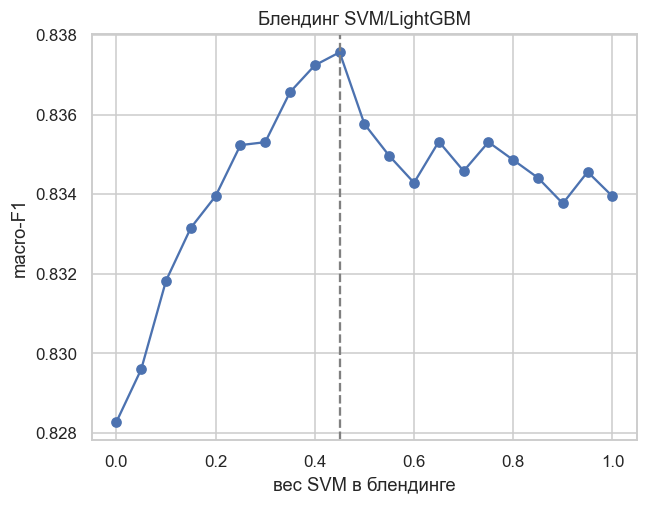

In [4]:
alphas = np.linspace(0, 1, 21)
scores = [macro_f1(a*svm_oof + (1-a)*lgbm_oof) for a in alphas]
best_a = alphas[int(np.argmax(scores))]
print(f"лучший вес alpha (доля SVM) = {best_a:.2f}")
print(f"blend macro-F1 = {max(scores):.4f}   (SVM {macro_f1(svm_oof):.4f}, LightGBM {macro_f1(lgbm_oof):.4f})")
plt.plot(alphas, scores, marker="o"); plt.axvline(best_a, ls="--", c="grey")
plt.xlabel("вес SVM в блендинге"); plt.ylabel("macro-F1"); plt.title("Блендинг SVM/LightGBM"); plt.show()
# Вывод: даже простое усреднение показывает, добавляет ли LightGBM что-то к SVM или тянет вниз.

## 4. Стекинг через мета-классификатор
Мета-признаки = конкатенация вероятностей обеих баз (8 чисел на строку). Мета-модель — логистическая регрессия.
Оцениваем её честно: `cross_val_predict` на **другом** разбиении (seed=7), т.к. мета-признаки уже OOF.

In [5]:
meta_X = np.hstack([svm_oof, lgbm_oof])
meta = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=1.0))
cv_meta = StratifiedKFold(5, shuffle=True, random_state=7)
stack_oof = cross_val_predict(meta, meta_X, y, cv=cv_meta, method="predict_proba", n_jobs=-1)
print(f"СТЕКИНГ macro-F1 = {macro_f1(stack_oof):.4f}")
print(f"  для сравнения: SVM={macro_f1(svm_oof):.4f}  LightGBM={macro_f1(lgbm_oof):.4f}  blend={max(scores):.4f}")
# Вывод: видно, превзошёл ли обученный мета-классификатор и одиночный SVM (0.834), и простое усреднение.

СТЕКИНГ macro-F1 = 0.8362
  для сравнения: SVM=0.8339  LightGBM=0.8283  blend=0.8376


## 5. Оптимизация порогов под macro-F1
На вероятностях стекинга подбираем пер-классовые веса (argmax `w_k·p_k`) координатным восхождением.
*Оговорка: настройка на тех же OOF — лёгкий оптимизм; на новых данных эффект чуть меньше.*

In [6]:
def tune_weights(proba, iters=4):
    w = np.ones(n_class); best = f1_score(y, proba.argmax(1), average="macro")
    for _ in range(iters):
        for k in range(n_class):
            for cand in np.linspace(0.5, 1.6, 23):
                w2 = w.copy(); w2[k] = cand
                s = f1_score(y, (proba*w2).argmax(1), average="macro")
                if s > best: best, w = s, w2
    return w, best
W, f1_w = tune_weights(stack_oof)
print(f"стекинг argmax     : {macro_f1(stack_oof):.4f}")
print(f"стекинг + веса     : {f1_w:.4f}   ({f1_w-macro_f1(stack_oof):+.4f})")
print("веса классов:", W.round(3))
# Вывод: пороги дают небольшой добор macro-F1 за счёт трудного класса 2.

стекинг argmax     : 0.8362
стекинг + веса     : 0.8382   (+0.0020)
веса классов: [0.5  0.95 0.95 0.65]


## 6. Анализ ошибок — стекинг

              precision    recall  f1-score   support

           0      0.891     0.841     0.866      2001
           1      0.844     0.869     0.856      2442
           2      0.775     0.811     0.792      2237
           3      0.850     0.828     0.839      2320

    accuracy                          0.838      9000
   macro avg      0.840     0.837     0.838      9000
weighted avg      0.839     0.838     0.838      9000



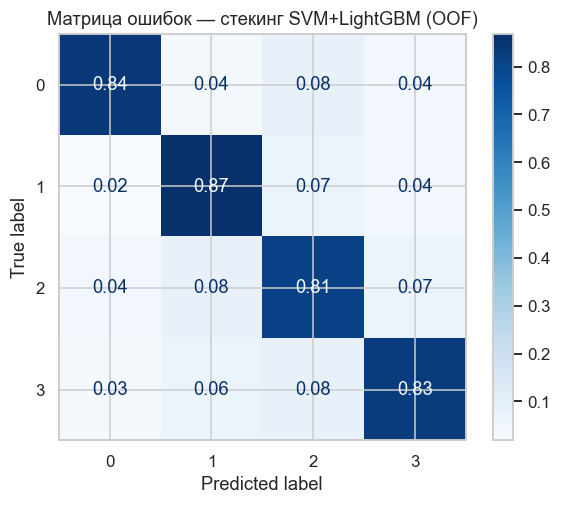

In [7]:
pred_oof = (stack_oof * W).argmax(1)
print(classification_report(y, pred_oof, digits=3))
ConfusionMatrixDisplay.from_predictions(y, pred_oof, normalize="true",
                                        display_labels=classes, cmap="Blues", values_format=".2f")
plt.title("Матрица ошибок — стекинг SVM+LightGBM (OOF)"); plt.show()
# Вывод: сравниваем recall класса 2 со SVM-линией — улучшил ли стекинг самое узкое место.

## 7. Финальная модель и сабмит
Переобучаем обе базы на **всех** train-данных, получаем их вероятности на test, мета-модель (обученная на полных
OOF мета-признаках) даёт финальный ответ, применяем веса классов.

In [8]:
# базы на полном train -> вероятности на test
svm_test = svm_pipe().fit(train[MODEL_FEATURES], y).predict_proba(test[MODEL_FEATURES])
n_round = int(np.mean(best_iters))
lgbm_full = lgb.train(BEST_LGBM, lgb.Dataset(Xl, y), num_boost_round=n_round)
lgbm_test = lgbm_full.predict(lgb_X(test))

# мета-модель на полных OOF мета-признаках -> предсказание на test
meta_full = meta.fit(meta_X, y)
stack_test = meta_full.predict_proba(np.hstack([svm_test, lgbm_test]))
pred_te = (stack_test * W).argmax(1)

submission = pd.DataFrame({"id": test["id"], target: pred_te})[sample_submission.columns]
submission.to_csv("submission_stack_svm_lgbm.csv", index=False)
print(f"Финальный OOF стекинга = {f1_w:.4f}   |   SVM-плато = 0.834")
print("Сохранено submission_stack_svm_lgbm.csv:", submission.shape)
comp = pd.DataFrame({"train": pd.Series(y).value_counts(normalize=True).sort_index(),
                     "test_pred": pd.Series(pred_te).value_counts(normalize=True).sort_index()}).round(3)
print("\nПроверка распределения классов:\n", comp)
submission.head()
# Вывод: финальный сабмит собран без утечки (базы рефитятся на полном train, мета — на OOF); распределение адекватно.

Финальный OOF стекинга = 0.8382   |   SVM-плато = 0.834
Сохранено submission_stack_svm_lgbm.csv: (5000, 2)

Проверка распределения классов:
    train  test_pred
0  0.222      0.212
1  0.271      0.263
2  0.249      0.274
3  0.258      0.252


,id,sleep_stage
0,9000,0
1,9001,3
2,9002,1
3,9003,2
4,9004,3


## 8. Итоги
- **Стекинг без утечки:** мета-признаки — OOF-вероятности баз; мета-модель оценена на отдельном разбиении.
- **Разнородность баз** (раздел 2) — необходимое условие выигрыша; здесь SVM и LightGBM расходятся на части объектов.
- **Честное сравнение:** базы → блендинг → стекинг → +пороги (разделы 1, 3, 4, 5) — видно, что и насколько помогло.
- **Вердикт:** если стекинг превысил 0.834 заметнее шума (~±0.001) — это лучший результат линии; если нет —
  значит две модели «видят» одни и те же объекты и предел данных подтверждён уже двумя независимыми семействами.